# 13 · Landmark reconciliation — F2 vs F15

**Question:** F2 (window Δ over [+6,+18] mo) shows **DBS prevents worsening** (p=0.017). F15 (Cox at NP1PAIN ≥ 2) shows **DBS reaches moderate pain FASTER** (HR 2.03, p=0.018) on longer follow-up. Are these contradictory or complementary?

**Approach — landmark analysis:** at L ∈ {6, 12, 18, 24, 36, 48, 60} months post-anchor, compute:
1. Arm means of NP1PAIN (raw and Δ from baseline).
2. Probability of NP1PAIN ≥ 2 and ≥ 3.
3. LMM-predicted NP1PAIN at L.
4. Landmark Cox: time-from-L until NP1PAIN ≥ 2 (patients still < 2 at L are eligible).

Produce one figure showing the DBS effect as a function of horizon. That single picture should resolve the tension.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(purrr); library(survival); library(lme4); library(emmeans); library(patchwork)
})
rel <- load_full_ppmi_rel_patient_anchor()
rel_d <- dedup_earliest_per_bin(rel)
cat("rel_d rows:", nrow(rel_d), "  patients:", dplyr::n_distinct(rel_d$PATNO), "\n")

landmarks <- c(6, 12, 18, 24, 36, 48, 60)

rel_d rows: 3535   patients: 1484 


In [2]:
# Per-patient baseline NP1PAIN (earliest visit in [−24, 0])
baseline_pain <- rel_d %>% dplyr::filter(months >= -24, months <= 0, !is.na(NP1PAIN)) %>%
  dplyr::arrange(PATNO, dplyr::desc(months)) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
  dplyr::select(PATNO, will_receive_dbs, pain_base = NP1PAIN)
cat("Patients with baseline:", nrow(baseline_pain), "\n")

# At each landmark, pull the closest observation (within a ±6 mo tolerance)
at_landmark <- function(L, tol = 6) {
  rel_d %>% dplyr::filter(!is.na(NP1PAIN),
                          months >= L - tol, months <= L + tol) %>%
    dplyr::mutate(dist = abs(months - L)) %>%
    dplyr::arrange(PATNO, dist, INFODT_orig) %>%
    dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
    dplyr::select(PATNO, NP1PAIN_L = NP1PAIN) %>%
    dplyr::mutate(landmark = L)
}

lm_df <- purrr::map_dfr(landmarks, at_landmark) %>%
  dplyr::inner_join(baseline_pain, by = "PATNO") %>%
  dplyr::mutate(delta = NP1PAIN_L - pain_base,
                moderate = as.integer(NP1PAIN_L >= 2),
                severe   = as.integer(NP1PAIN_L >= 3),
                arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"))
print(lm_df %>% dplyr::count(landmark, arm, name = "n") %>% tidyr::pivot_wider(names_from = arm, values_from = n))

Patients with baseline: 1484 


# A tibble: 7 × 3
  landmark   DBS `Never-DBS`
     <dbl> <int>       <int>
1        6   105        1379
2       12    67         575
3       18    75         659
4       24    49         348
5       36    33         156
6       48    15          98
7       60     9          67


In [3]:
# ------- Panel A: mean NP1PAIN at each landmark, by arm -------
lm_summ <- lm_df %>% dplyr::group_by(landmark, arm) %>%
  dplyr::summarise(n = dplyr::n(),
                   mean_pain = mean(NP1PAIN_L),
                   se = stats::sd(NP1PAIN_L) / sqrt(n),
                   mean_delta = mean(delta),
                   se_delta = stats::sd(delta) / sqrt(n),
                   p_moderate = mean(moderate),
                   p_severe = mean(severe),
                   .groups = "drop") %>%
  dplyr::mutate(lo_pain = mean_pain - 1.96 * se, hi_pain = mean_pain + 1.96 * se,
                lo_d    = mean_delta - 1.96 * se_delta, hi_d = mean_delta + 1.96 * se_delta)
print(lm_summ)
save_table(lm_summ, "landmark_summary")

# Welch test per landmark
welch_tbl <- purrr::map_dfr(landmarks, function(L) {
  d_dbs <- lm_df %>% dplyr::filter(landmark == L, arm == "DBS") %>% dplyr::pull(delta)
  d_ctl <- lm_df %>% dplyr::filter(landmark == L, arm == "Never-DBS") %>% dplyr::pull(delta)
  if (length(d_dbs) < 5 || length(d_ctl) < 5) return(tibble::tibble(landmark = L, t = NA, p = NA, diff = NA))
  tt <- stats::t.test(d_dbs, d_ctl)
  tibble::tibble(landmark = L, diff = mean(d_dbs) - mean(d_ctl),
                 lo = tt$conf.int[1], hi = tt$conf.int[2],
                 t = tt$statistic, p = tt$p.value)
})
print(welch_tbl)
save_table(welch_tbl, "landmark_delta_welch")

# A tibble: 14 × 13
   landmark arm       n mean_pain     se mean_delta se_delta p_moderate p_severe
      <dbl> <chr> <int>     <dbl>  <dbl>      <dbl>    <dbl>      <dbl>    <dbl>
 1        6 DBS     105     1.23  0.120    -0.0476   0.0626       0.295   0.171 
 2        6 Neve…  1379     0.854 0.0259   -0.00363  0.00348      0.183   0.0827
 3       12 DBS      67     1.34  0.148     0.104    0.117        0.358   0.209 
 4       12 Neve…   575     0.871 0.0412    0.0243   0.0427       0.2     0.0870
 5       18 DBS      75     1.33  0.141     0.12     0.109        0.36    0.2   
 6       18 Neve…   659     0.868 0.0379    0.0152   0.0392       0.197   0.0835
 7       24 DBS      49     1.20  0.146     0.102    0.134        0.327   0.122 
 8       24 Neve…   348     0.922 0.0489    0.101    0.0575       0.227   0.0718
 9       36 DBS      33     1.52  0.190     0.212    0.161        0.455   0.212 
10       36 Neve…   156     0.936 0.0812    0.115    0.0918       0.212   0.115 
11      

# A tibble: 7 × 6
  landmark     diff     lo     hi       t     p
     <dbl>    <dbl>  <dbl>  <dbl>   <dbl> <dbl>
1        6 -0.0440  -0.168 0.0803 -0.702  0.484
2       12  0.0801  -0.167 0.327   0.645  0.521
3       18  0.105   -0.125 0.335   0.905  0.368
4       24  0.00147 -0.290 0.293   0.0100 0.992
5       36  0.0967  -0.275 0.469   0.521  0.605
6       48 -0.282   -0.842 0.279  -1.04   0.308
7       60 -0.0531  -0.596 0.490  -0.203  0.841


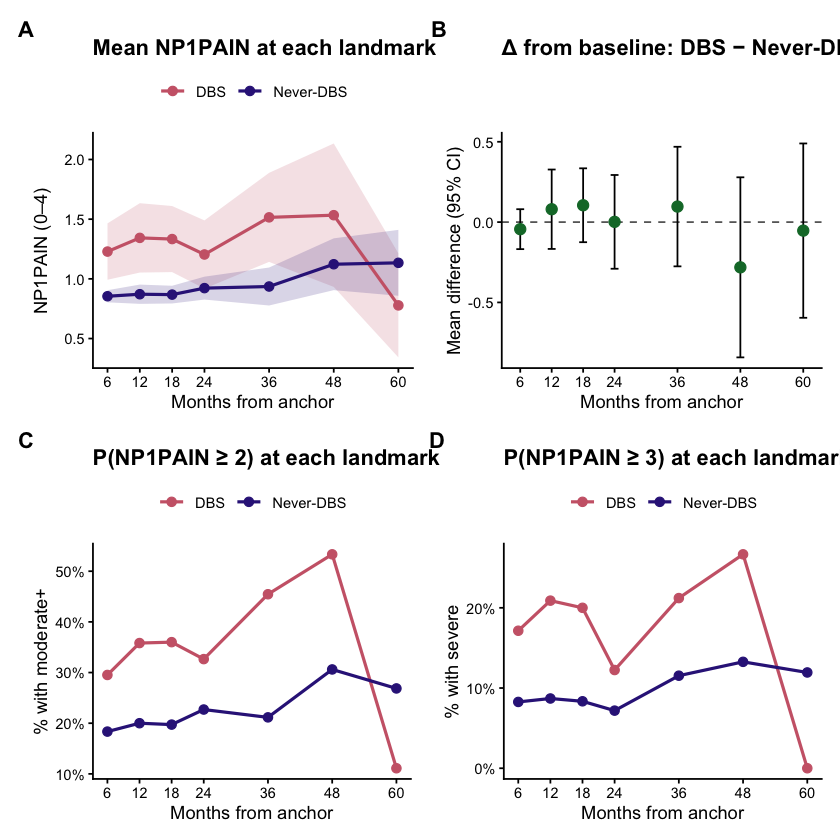

In [4]:
# Panel A — mean NP1PAIN
pA <- ggplot(lm_summ, aes(landmark, mean_pain, colour = arm, fill = arm)) +
  geom_ribbon(aes(ymin = lo_pain, ymax = hi_pain), alpha = 0.18, colour = NA) +
  geom_line(linewidth = 0.9) + geom_point(size = 2.3) +
  scale_colour_manual(values = c(`DBS` = "#CC6677", `Never-DBS` = "#332288"), name = NULL) +
  scale_fill_manual(values = c(`DBS` = "#CC6677", `Never-DBS` = "#332288"), guide = "none") +
  scale_x_continuous(breaks = landmarks) +
  labs(title = "Mean NP1PAIN at each landmark", x = "Months from anchor", y = "NP1PAIN (0–4)", tag = "A") +
  theme_classic(base_size = 11) + theme(plot.tag = element_text(face = "bold"), legend.position = "top", plot.title = element_text(face = "bold"))

# Panel B — Δ NP1PAIN (arm minus arm)
welch_tbl <- welch_tbl %>% dplyr::mutate(signif = ifelse(p < 0.05, "*", ""))
pB <- ggplot(welch_tbl, aes(landmark, diff)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(ymin = lo, ymax = hi), width = 1.5) +
  geom_point(colour = "#117733", size = 2.8) +
  geom_text(aes(label = signif), vjust = -1.2, size = 5, colour = "#117733") +
  scale_x_continuous(breaks = landmarks) +
  labs(title = "Δ from baseline: DBS − Never-DBS", x = "Months from anchor",
       y = "Mean difference (95% CI)", tag = "B") +
  theme_classic(base_size = 11) + theme(plot.tag = element_text(face = "bold"), plot.title = element_text(face = "bold"))

# Panel C — P(NP1PAIN ≥ 2)
pC <- ggplot(lm_summ, aes(landmark, p_moderate, colour = arm, group = arm)) +
  geom_line(linewidth = 0.9) + geom_point(size = 2.3) +
  scale_colour_manual(values = c(`DBS` = "#CC6677", `Never-DBS` = "#332288"), name = NULL) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_x_continuous(breaks = landmarks) +
  labs(title = "P(NP1PAIN ≥ 2) at each landmark", x = "Months from anchor", y = "% with moderate+", tag = "C") +
  theme_classic(base_size = 11) + theme(plot.tag = element_text(face = "bold"), legend.position = "top", plot.title = element_text(face = "bold"))

# Panel D — P(NP1PAIN ≥ 3)
pD <- ggplot(lm_summ, aes(landmark, p_severe, colour = arm, group = arm)) +
  geom_line(linewidth = 0.9) + geom_point(size = 2.3) +
  scale_colour_manual(values = c(`DBS` = "#CC6677", `Never-DBS` = "#332288"), name = NULL) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_x_continuous(breaks = landmarks) +
  labs(title = "P(NP1PAIN ≥ 3) at each landmark", x = "Months from anchor", y = "% with severe", tag = "D") +
  theme_classic(base_size = 11) + theme(plot.tag = element_text(face = "bold"), legend.position = "top", plot.title = element_text(face = "bold"))

fig_land <- (pA | pB) / (pC | pD)
fig_land
save_fig(fig_land, "Figure8_landmark", width = 11, height = 7)

In [5]:
# Landmark Cox: start clock AT landmark L, outcome = first NP1PAIN ≥ 2 after L.
# Requires patient to be < 2 at L.
landmark_cox <- function(L) {
  at_L <- lm_df %>% dplyr::filter(landmark == L, NP1PAIN_L < 2) %>%
    dplyr::select(PATNO, will_receive_dbs, pain_base)
  if (nrow(at_L) < 30) return(NULL)
  post <- rel_d %>% dplyr::filter(months > L, !is.na(NP1PAIN), PATNO %in% at_L$PATNO) %>%
    dplyr::arrange(PATNO, months)
  ev <- post %>% dplyr::group_by(PATNO) %>%
    dplyr::summarise(
      event_time = { hi <- which(NP1PAIN >= 2);
                     if (length(hi) > 0) months[hi[1]] - L else max(months, na.rm = TRUE) - L },
      event = as.integer(any(NP1PAIN >= 2)),
      .groups = "drop"
    ) %>% dplyr::filter(is.finite(event_time), event_time > 0)
  ev <- ev %>% dplyr::inner_join(at_L, by = "PATNO")
  if (nrow(ev) < 30 || sum(ev$event) < 5) return(NULL)
  cox <- survival::coxph(survival::Surv(event_time, event) ~ will_receive_dbs + pain_base,
                         data = ev)
  co <- summary(cox)$coefficients
  ci <- summary(cox)$conf.int
  tibble::tibble(
    landmark = L, n = nrow(ev), events = sum(ev$event),
    HR = ci["will_receive_dbsTRUE", "exp(coef)"],
    lo = ci["will_receive_dbsTRUE", "lower .95"],
    hi = ci["will_receive_dbsTRUE", "upper .95"],
    p  = co["will_receive_dbsTRUE", "Pr(>|z|)"]
  )
}
cox_tbl <- purrr::map_dfr(landmarks, landmark_cox)
print(cox_tbl)
save_table(cox_tbl, "landmark_cox_hr")

# A tibble: 6 × 7
  landmark     n events    HR    lo    hi     p
     <dbl> <int>  <int> <dbl> <dbl> <dbl> <dbl>
1        6   726    194 1.38  0.888  2.13 0.154
2       12   315     90 1.24  0.642  2.41 0.518
3       18   390    100 1.17  0.624  2.18 0.629
4       24   141     40 0.600 0.185  1.95 0.395
5       36    63     19 0.849 0.190  3.80 0.830
6       60    30     10 0.973 0.119  7.94 0.979


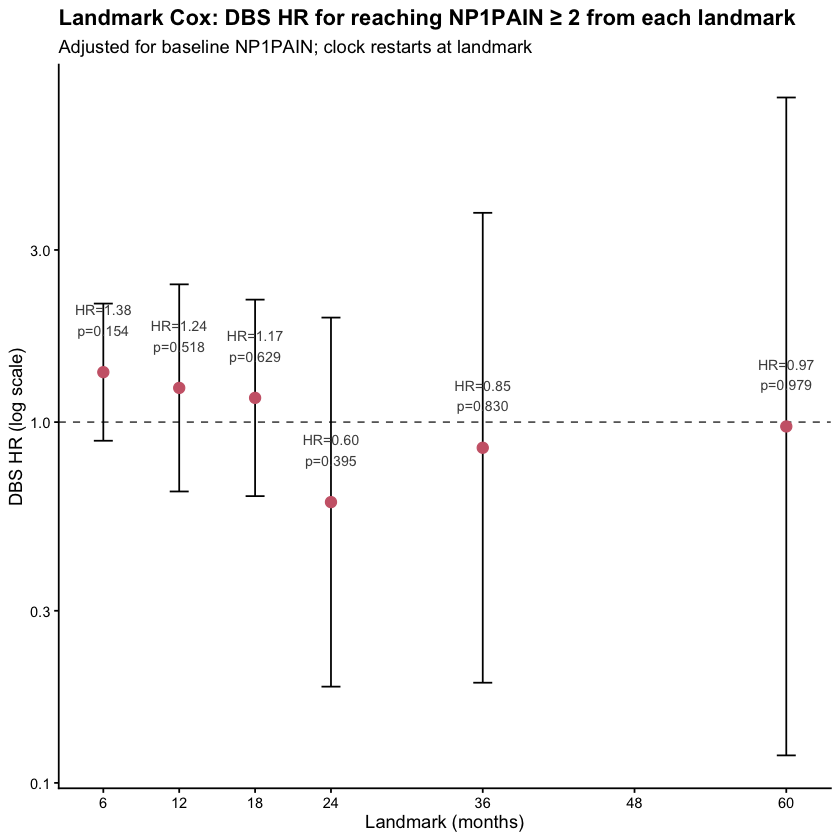

In [6]:
p_cox <- ggplot(cox_tbl, aes(landmark, HR)) +
  geom_hline(yintercept = 1, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(ymin = lo, ymax = hi), width = 1.5) +
  geom_point(colour = "#CC6677", size = 2.8) +
  geom_text(aes(label = sprintf("HR=%.2f\np=%.3f", HR, p)),
            vjust = -1.2, size = 3, colour = "grey30") +
  scale_y_log10() +
  scale_x_continuous(breaks = landmarks) +
  labs(title = "Landmark Cox: DBS HR for reaching NP1PAIN ≥ 2 from each landmark",
       subtitle = "Adjusted for baseline NP1PAIN; clock restarts at landmark",
       x = "Landmark (months)", y = "DBS HR (log scale)") +
  theme_classic(base_size = 11) +
  theme(plot.title = element_text(face = "bold"))
p_cox
save_fig(p_cox, "Figure9_landmark_cox", width = 9, height = 4.4)

In [7]:
# LMM-predicted NP1PAIN at each landmark for each arm (using years scale)
lmm_data <- rel %>% dplyr::filter(!is.na(NP1PAIN)) %>%
  dplyr::mutate(time = time_months / 12,
                arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"),
                arm = factor(arm, levels = c("Never-DBS","DBS")))
m <- lme4::lmer(NP1PAIN ~ time * arm + (1 + time | PATNO), data = lmm_data, REML = FALSE,
                control = lme4::lmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5)))

grid <- expand.grid(time = landmarks/12,
                    arm = factor(c("Never-DBS","DBS"), levels = c("Never-DBS","DBS")))
pr <- predict(m, newdata = grid, re.form = NA, se.fit = TRUE)
pred <- dplyr::bind_cols(grid, tibble::tibble(fit = pr$fit, lci = pr$fit - 1.96*pr$se.fit,
                                              uci = pr$fit + 1.96*pr$se.fit)) %>%
  dplyr::mutate(landmark = time * 12)
print(pred)
save_table(pred, "lmm_landmark_predictions")

# Effect = DBS − Never-DBS at each landmark
eff <- pred %>% dplyr::select(landmark, arm, fit) %>%
  tidyr::pivot_wider(names_from = arm, values_from = fit) %>%
  dplyr::mutate(diff = DBS - `Never-DBS`)
print(eff)

   time       arm       fit       lci       uci landmark
1   0.5 Never-DBS 0.9387013 0.8912324 0.9861701        6
2   1.0 Never-DBS 0.9454682 0.8967638 0.9941726       12
3   1.5 Never-DBS 0.9522351 0.8989315 1.0055387       18
4   2.0 Never-DBS 0.9590020 0.8984978 1.0195062       24
5   3.0 Never-DBS 0.9725358 0.8928444 1.0522272       36
6   4.0 Never-DBS 0.9860696 0.8838836 1.0882557       48
7   5.0 Never-DBS 0.9996035 0.8733713 1.1258356       60
8   0.5       DBS 1.2491892 1.0929249 1.4054535        6
9   1.0       DBS 1.2757204 1.1196798 1.4317610       12
10  1.5       DBS 1.3022516 1.1395607 1.4649424       18
11  2.0       DBS 1.3287827 1.1533478 1.5042177       24
12  3.0       DBS 1.3818451 1.1674527 1.5962375       36
13  4.0       DBS 1.4349074 1.1705048 1.6993100       48
14  5.0       DBS 1.4879697 1.1676398 1.8082997       60


# A tibble: 7 × 4
  landmark `Never-DBS`   DBS  diff
     <dbl>       <dbl> <dbl> <dbl>
1        6       0.939  1.25 0.310
2       12       0.945  1.28 0.330
3       18       0.952  1.30 0.350
4       24       0.959  1.33 0.370
5       36       0.973  1.38 0.409
6       48       0.986  1.43 0.449
7       60       1.000  1.49 0.488
